### Setup Environment

In [1]:
# Import libraries
import os
import opensmile
import pandas as pd
import librosa
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [2]:
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go


### Define Directories and Feature Sets

In [3]:
import os
import opensmile
import librosa
import numpy as np
import pandas as pd
import parselmouth
from tqdm import tqdm

class AudioFeatureExtractor:
    def __init__(self):
        # Initialize OpenSMILE
        self.feature_sets = [
            'ComParE_2016', 'eGeMAPSv01a', 'eGeMAPSv01b', 'eGeMAPSv02',
            'emobase', 'GeMAPSv01a', 'GeMAPSv01b'
        ]
        self.feature_levels = ['Functionals', 'LowLevelDescriptors']
        
        self.smile_instances = []
        for feature_set in self.feature_sets:
            for level in self.feature_levels:
                self.smile_instances.append(
                    opensmile.Smile(
                        feature_set=getattr(opensmile.FeatureSet, feature_set),
                        feature_level=getattr(opensmile.FeatureLevel, level)
                    )
                )
        
        # Define prefixes
        self.OPENSMILE_PREFIX = "os_"
        self.LIBROSA_PREFIX = "lb_"
        self.PRAAT_PREFIX = "pr_"

    def extract_opensmile_features(self, file_path):
        """Extract OpenSMILE features with prefix"""
        opensmile_features = {}
        for smile in self.smile_instances:
            try:
                features = smile.process_file(file_path)
                # Add prefix to each feature
                for key, value in features.to_dict(orient='records')[0].items():
                    opensmile_features[f"{self.OPENSMILE_PREFIX}{key}"] = value
            except Exception as e:
                print(f"OpenSMILE error for {file_path}: {e}")
        return opensmile_features

    def extract_librosa_features(self, file_path):
        """Extract Librosa features with prefix"""
        try:
            y, sr = librosa.load(file_path, sr=None)
            features = {
                "mfcc_mean": np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13), axis=1),
                "mfcc_std": np.std(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13), axis=1),
                "rolloff_mean": np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)),
                "rolloff_std": np.std(librosa.feature.spectral_rolloff(y=y, sr=sr)),
                "zcr_mean": np.mean(librosa.feature.zero_crossing_rate(y)),
                "zcr_std": np.std(librosa.feature.zero_crossing_rate(y)),
                "centroid_mean": np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)),
                "centroid_std": np.std(librosa.feature.spectral_centroid(y=y, sr=sr)),
            }
            
            # Add prefix to features
            return {f"{self.LIBROSA_PREFIX}{k}": v for k, v in features.items()}
        except Exception as e:
            print(f"Librosa error for {file_path}: {e}")
            return {}

    def extract_praat_features(self, file_path):
        """Extract Praat features with prefix"""
        try:
            # Load the audio file using Parselmouth
            sound = parselmouth.Sound(file_path)

            # Initialize dictionary for Praat features
            praat_features = {}

            # Extract jitter and shimmer (via Praat commands)
            point_process = parselmouth.praat.call(sound, "To PointProcess (periodic, cc)", 75, 500)
            praat_features["jitter_local"] = parselmouth.praat.call(
                point_process, "Get jitter (local)", 0.0001, 0.02, 1.3, 1.6
            )
            praat_features["jitter_ddp"] = parselmouth.praat.call(
                point_process, "Get jitter (ddp)", 0.0001, 0.02, 1.3, 1.6
            )
            praat_features["shimmer_local"] = parselmouth.praat.call(
                [sound, point_process], "Get shimmer (local)", 0.0001, 0.02, 1.3, 1.6, 0.05, 1.6
            )
            praat_features["shimmer_apq3"] = parselmouth.praat.call(
                [sound, point_process], "Get shimmer (apq3)", 0.0001, 0.02, 1.3, 1.6, 0.05, 1.6
            )
            praat_features["shimmer_apq5"] = parselmouth.praat.call(
                [sound, point_process], "Get shimmer (apq5)", 0.0001, 0.02, 1.3, 1.6, 0.05, 1.6
            )

            # Extract Harmonics-to-Noise Ratio (HNR)
            praat_features["hnr"] = parselmouth.praat.call(sound, "Get HNR", 0.1, 0.25)

            # Extract formant frequencies using Burg's method
            formant = sound.to_formant_burg(time_step=0.01, max_number_of_formants=5, maximum_formant=5500)
            praat_features["formant1_mean"] = parselmouth.praat.call(formant, "Get mean", 1, 0, 0)
            praat_features["formant2_mean"] = parselmouth.praat.call(formant, "Get mean", 2, 0, 0)
            praat_features["formant3_mean"] = parselmouth.praat.call(formant, "Get mean", 3, 0, 0)
            praat_features["formant1_std"] = parselmouth.praat.call(formant, "Get standard deviation", 1, 0, 0)
            praat_features["formant2_std"] = parselmouth.praat.call(formant, "Get standard deviation", 2, 0, 0)
            praat_features["formant3_std"] = parselmouth.praat.call(formant, "Get standard deviation", 3, 0, 0)

            # Add prefix to features
            return {f"{self.PRAAT_PREFIX}{k}": v for k, v in praat_features.items()}

        except Exception as e:
            print(f"Error extracting Praat features for {file_path}: {e}")
            return {}

    # [Keep the rest of the AudioFeatureExtractor class methods the same]

    def extract_all_features(self, file_path):
        """Extract all features with prefixes"""
        features = {}
        
        # Extract features from each library
        opensmile_features = self.extract_opensmile_features(file_path)
        librosa_features = self.extract_librosa_features(file_path)
        praat_features = self.extract_praat_features(file_path)
        
        # Combine all features
        features.update(opensmile_features)
        features.update(librosa_features)
        features.update(praat_features)
        
        # Add feature counts
        features['opensmile_count'] = len(opensmile_features)
        features['librosa_count'] = len(librosa_features)
        features['praat_count'] = len(praat_features)
        features['total_features'] = len(features)
        
        return features

### Extract Features for All Feature Sets and Levels

In [4]:
def process_directory(directory, label, extractor):
    """Process all files in a directory"""
    feature_data = []
    wav_files = [f for f in os.listdir(directory) if f.endswith('.wav')]
    
    for file_name in tqdm(wav_files, desc=f"Processing {os.path.basename(directory)}"):
        file_path = os.path.join(directory, file_name)
        try:
            features = extractor.extract_all_features(file_path)
            features["file_name"] = file_name
            features["label"] = label
            feature_data.append(features)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    
    return feature_data

In [ ]:
def main():
    # Initialize feature extractor
    extractor = AudioFeatureExtractor()
    
    # Define directories
    data_dir = r"C:\Users\sreev\OneDrive\Desktop\Parkinsons\Voice Samples for Patients with Parkinson's Disease and Healthy Controls_rd"
    healthy_dir = os.path.join(data_dir, "HC")
    parkinson_dir = os.path.join(data_dir, "PD")
    
    # Initialize feature data list
    feature_data = []
    
    # Process healthy controls
    print("Processing healthy controls...")
    healthy_data = process_directory(healthy_dir, label=0, extractor=extractor)
    feature_data.extend(healthy_data)
    
    # Process Parkinson's patients
    print("\nProcessing Parkinson's patients...")
    parkinson_data = process_directory(parkinson_dir, label=1, extractor=extractor)
    feature_data.extend(parkinson_data)
    
    # Convert to DataFrame and save
    features_df = pd.DataFrame(feature_data)
    output_file = "combined_features_081.csv"
    features_df.to_csv(output_file, index=False)
    
    # Print summary
    print(f"\nFeature extraction complete. Features saved to {output_file}")
    print("\nExtraction Summary:")
    print(f"Total files processed: {len(features_df)}")
    print(f"Healthy controls: {len(features_df[features_df['label'] == 0])}")
    print(f"Parkinson's patients: {len(features_df[features_df['label'] == 1])}")
    if len(features_df) > 0:
        print(f"Total features per file: {features_df['total_features'].iloc[0]}")
        print("\nFeature counts:")
        print(f"OpenSMILE features: {features_df['opensmile_count'].iloc[0]}")
        print(f"Librosa features: {features_df['librosa_count'].iloc[0]}")
        print(f"Praat features: {features_df['praat_count'].iloc[0]}")

if __name__ == "__main__":
    main()

Processing healthy controls...


Processing HC:   5%|▍         | 1/22 [01:43<36:22, 103.94s/it]

Error extracting Praat features for C:\Users\sreev\OneDrive\Desktop\Parkinsons\Voice Samples for Patients with Parkinson's Disease and Healthy Controls_rd\HC\ID00_hc_0_0_0.wav: Command requires more than the given 4 arguments: no value for argument "Maximum period factor".


In [5]:
dataset = pd.read_csv("combined_features_081.csv")

# Display the first few rows
print(dataset.head())

# Display basic info about the dataset
print(dataset.info())

# Summary statistics of numerical columns
print(dataset.describe())


   os_audspec_lengthL1norm_sma_range  os_audspec_lengthL1norm_sma_maxPos  \
0                           1.068221                            0.229012   
1                           6.369210                            0.493568   
2                           1.439469                            0.892386   
3                           1.419298                            0.484889   
4                           2.324570                            0.133192   

   os_audspec_lengthL1norm_sma_minPos  os_audspec_lengthL1norm_sma_quartile1  \
0                            0.053761                               0.070124   
1                            0.760166                               0.081711   
2                            0.905793                               0.089911   
3                            0.700226                               0.068416   
4                            0.444155                               0.074566   

   os_audspec_lengthL1norm_sma_quartile2  \
0                 

In [6]:
df=dataset[:]

In [7]:
df.drop("file_name", axis=1)

,os_audspec_lengthL1norm_sma_range,os_audspec_lengthL1norm_sma_maxPos,os_audspec_lengthL1norm_sma_minPos,os_audspec_lengthL1norm_sma_quartile1,os_audspec_lengthL1norm_sma_quartile2,os_audspec_lengthL1norm_sma_quartile3,os_audspec_lengthL1norm_sma_iqr1-2,os_audspec_lengthL1norm_sma_iqr2-3,os_audspec_lengthL1norm_sma_iqr1-3,os_audspec_lengthL1norm_sma_percentile1.0,...,lb_rolloff_std,lb_zcr_mean,lb_zcr_std,lb_centroid_mean,lb_centroid_std,opensmile_count,librosa_count,praat_count,total_features,label
0,1.068221,0.229012,0.053761,0.070124,0.142961,0.253994,0.072837,0.111032,0.183870,0.041453,...,5199.429991,0.078671,0.090998,4145.632542,2330.139801,7188,8,0,7199,0
1,6.369210,0.493568,0.760166,0.081711,0.370981,0.694179,0.289270,0.323198,0.612468,0.039616,...,4349.104197,0.096239,0.105654,4914.428175,2458.087281,7188,8,0,7199,0
2,1.439469,0.892386,0.905793,0.089911,0.195657,0.352913,0.105746,0.157256,0.263002,0.042567,...,5377.237335,0.086954,0.090219,4144.127362,2432.865223,7188,8,0,7199,0
3,1.419298,0.484889,0.700226,0.068416,0.244612,0.444998,0.176196,0.200386,0.376582,0.041061,...,5555.861414,0.089911,0.100396,4473.216471,2631.507539,7188,8,0,7199,0
4,2.324570,0.133192,0.444155,0.074566,0.182165,0.314206,0.107599,0.132041,0.239640,0.035791,...,5130.270252,0.096233,0.104851,4454.264244,2461.130183,7188,8,0,7199,0
5,1.870663,0.141388,0.519458,0.061608,0.196951,0.365395,0.135344,0.168444,0.303787,0.032335,...,4896.742224,0.103472,0.111162,5164.314146,2639.562889,7188,8,0,7199,0
6,2.085477,0.906291,0.878493,0.079178,0.212332,0.413533,0.133154,0.201201,0.334355,0.044516,...,5354.603217,0.088560,0.105497,4457.359932,2657.107240,7188,8,0,7199,0
7,0.883342,0.166273,0.055424,0.043023,0.115201,0.241436,0.072178,0.126236,0.198414,0.029963,...,5510.066722,0.091658,0.103316,4932.043581,2602.458446,7188,8,0,7199,0
8,1.780565,0.709106,0.198835,0.064453,0.175379,0.383468,0.110925,0.208090,0.319015,0.034262,...,5255.977184,0.089864,0.100429,4502.395682,2469.954110,7188,8,0,7199,0
9,0.932374,0.743614,0.346798,0.053095,0.123460,0.217827,0.070365,0.094367,0.164733,0.033745,...,4802.823200,0.101355,0.109156,5115.553527,2606.626353,7188,8,0,7199,0


In [8]:
import re
import ast
import numpy as np

# Step 1: Fix formatting in MFCC columns (now with 'lb_' prefix)
def fix_format(value):
    if isinstance(value, str):
        fixed_value = re.sub(r'(?<=\d)\s+(?=[-\d])', ', ', value)
        try:
            return ast.literal_eval(fixed_value)
        except:
            return None
    return value

# Apply fix_format to prefixed MFCC columns
df['lb_mfcc_mean'] = df['lb_mfcc_mean'].apply(fix_format)
df['lb_mfcc_std'] = df['lb_mfcc_std'].apply(fix_format)

# Step 2: Compute global statistics for 'lb_mfcc_mean'
df['lb_global_mfcc_mean'] = df['lb_mfcc_mean'].apply(lambda x: np.mean(x) if x is not None else None)
df['lb_global_mfcc_mean_std'] = df['lb_mfcc_mean'].apply(lambda x: np.std(x) if x is not None else None)
df['lb_global_mfcc_mean_min'] = df['lb_mfcc_mean'].apply(lambda x: np.min(x) if x is not None else None)
df['lb_global_mfcc_mean_max'] = df['lb_mfcc_mean'].apply(lambda x: np.max(x) if x is not None else None)

# Step 3: Compute global statistics for 'lb_mfcc_std'
df['lb_global_mfcc_std_mean'] = df['lb_mfcc_std'].apply(lambda x: np.mean(x) if x is not None else None)
df['lb_global_mfcc_std_std'] = df['lb_mfcc_std'].apply(lambda x: np.std(x) if x is not None else None)
df['lb_global_mfcc_std_min'] = df['lb_mfcc_std'].apply(lambda x: np.min(x) if x is not None else None)
df['lb_global_mfcc_std_max'] = df['lb_mfcc_std'].apply(lambda x: np.max(x) if x is not None else None)

# Step 4: Drop the original list-based columns
df = df.drop(columns=['lb_mfcc_mean', 'lb_mfcc_std'])

# Save the processed dataset
df.to_csv("processed_features_for_ml_081.csv", index=False)
print("Global statistics calculated and dataset saved as 'processed_features_for_ml_081.csv'.")

Global statistics calculated and dataset saved as 'processed_features_for_ml_081.csv'.


**Column Names**

In [9]:
df.columns

Index(['os_audspec_lengthL1norm_sma_range',
       'os_audspec_lengthL1norm_sma_maxPos',
       'os_audspec_lengthL1norm_sma_minPos',
       'os_audspec_lengthL1norm_sma_quartile1',
       'os_audspec_lengthL1norm_sma_quartile2',
       'os_audspec_lengthL1norm_sma_quartile3',
       'os_audspec_lengthL1norm_sma_iqr1-2',
       'os_audspec_lengthL1norm_sma_iqr2-3',
       'os_audspec_lengthL1norm_sma_iqr1-3',
       'os_audspec_lengthL1norm_sma_percentile1.0',
       ...
       'file_name', 'label', 'lb_global_mfcc_mean', 'lb_global_mfcc_mean_std',
       'lb_global_mfcc_mean_min', 'lb_global_mfcc_mean_max',
       'lb_global_mfcc_std_mean', 'lb_global_mfcc_std_std',
       'lb_global_mfcc_std_min', 'lb_global_mfcc_std_max'],
      dtype='object', length=7208)

In [10]:
df=df.drop("file_name", axis=1)

In [11]:
correlations = df.corrwith(df['label']).sort_values(ascending=False)
print("Feature Correlations with Label:\n", correlations)


Feature Correlations with Label:
 label                                                     1.000000
os_pcm_fftMag_spectralSkewness_sma_percentile1.0          0.748721
os_pcm_fftMag_spectralRollOff50.0_sma_de_percentile1.0    0.683342
os_audSpec_Rfilt_sma[8]_minRangeRel                       0.682789
os_pcm_fftMag_spectralRollOff25.0_sma_de_percentile1.0    0.665361
                                                            ...   
os_F0env_sma_de_quartile2                                      NaN
opensmile_count                                                NaN
librosa_count                                                  NaN
praat_count                                                    NaN
total_features                                                 NaN
Length: 7207, dtype: float64


In [12]:
correlation_matrix = df.corr()

# Correlation of features with the label
label_correlation = correlation_matrix['label']

# Step 2: Find highly correlated pairs (absolute correlation > 0.9)
threshold = 0.9
high_corr_pairs = []

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[1]):  # Avoid self-correlation
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((correlation_matrix.index[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

# Display highly correlated pairs
high_corr_pairs = sorted(high_corr_pairs, key=lambda x: -abs(x[2]))  # Sort by correlation value
for pair in high_corr_pairs:
    print(f"{pair[0]} and {pair[1]}: Correlation = {pair[2]:.2f}")

os_F0env_sma_min and os_F0_sma: Correlation = 1.00
os_pcm_fftMag_spectralRollOff25.0_sma_percentile99.0 and os_pcm_fftMag_spectralRollOff25.0_sma_pctlrange0-1: Correlation = 1.00
os_pcm_fftMag_spectralEntropy_sma_minSegLen and os_mfcc_sma[1]_minSegLen: Correlation = 1.00
os_F0final_sma_amean and os_F0final_sma_posamean: Correlation = 1.00
os_voicingFinalUnclipped_sma_amean and os_voicingFinalUnclipped_sma_posamean: Correlation = 1.00
os_jitterLocal_sma_amean and os_jitterLocal_sma_posamean: Correlation = 1.00
os_jitterDDP_sma_amean and os_jitterDDP_sma_posamean: Correlation = 1.00
os_shimmerLocal_sma_amean and os_shimmerLocal_sma_posamean: Correlation = 1.00
os_pcm_fftMag_spectralCentroid_sma_de_peakMeanRel and os_pcm_fftMag_psySharpness_sma_de_peakMeanRel: Correlation = 1.00
os_audspec_lengthL1norm_sma and os_Loudness_sma3: Correlation = 1.00
os_F0_sma_max and os_F0_sma_range: Correlation = 1.00
os_F0_sma_quartile2 and os_F0_sma_iqr1-2: Correlation = 1.00
os_F0_sma_quartile3 and os_F0

In [13]:
features_to_drop = set()

for feature1, feature2, _ in high_corr_pairs:  # Unpack the correlation value as `_`
    # Compare correlation with the label
    if abs(label_correlation[feature1]) > abs(label_correlation[feature2]):
        features_to_drop.add(feature2)  # Drop feature2
    else:
        features_to_drop.add(feature1)  # Drop feature1

# Step 4: Drop the selected features from the dataset
df_reduced = df.drop(columns=features_to_drop)

print(f"Features dropped: {features_to_drop}")
print(f"Reduced dataset now has {df_reduced.shape[1]} features.")

Features dropped: {'os_audSpec_Rfilt_sma[23]_meanRisingSlope', 'os_audSpec_Rfilt_sma_de[10]_meanPeakDist', 'os_mfcc_sma_de[2]_min', 'os_pcm_intensity_sma_range', 'os_pcm_RMSenergy_sma_meanRisingSlope', 'os_audSpec_Rfilt_sma_de[16]_quartile3', 'os_audSpec_Rfilt_sma[2]_quartile3', 'os_lspFreq_sma[6]_quartile2', 'os_mfcc_sma_de[2]_lpgain', 'os_pcm_fftMag_spectralFlux_sma_segLenStddev', 'os_pcm_zcr_sma_lpc1', 'os_audSpec_Rfilt_sma[20]_qregc2', 'os_lspFreq_sma[5]_iqr1-3', 'os_pcm_zcr_sma_meanRisingSlope', 'os_pcm_fftMag_spectralCentroid_sma_minSegLen', 'os_audSpec_Rfilt_sma_de[11]_maxPos', 'os_audSpec_Rfilt_sma_de[2]_iqr1-3', 'os_audSpec_Rfilt_sma[19]_upleveltime50', 'os_audSpec_Rfilt_sma_de[0]_meanRisingSlope', 'os_mfcc_sma[6]_iqr1-2', 'os_audSpec_Rfilt_sma[16]_risetime', 'os_pcm_fftMag_spectralRollOff25.0_sma_de_lpc0', 'os_audSpec_Rfilt_sma[6]_amean', 'os_audSpec_Rfilt_sma[2]_stddev', 'os_audSpec_Rfilt_sma_de[24]_stddevFallingSlope', 'os_audSpec_Rfilt_sma_de[5]_peakMeanAbs', 'os_mfcc_sma[

In [14]:
df_reduced.to_csv("reduced_features_for_ml_081.csv", index=False)
print("Reduced dataset saved as 'reduced_features_for_ml_081.csv'")


Reduced dataset saved as 'reduced_features_for_ml_081.csv'


In [19]:
import pandas as pd

def safe_select_columns(df, desired_columns):
    """
    Safely select columns from a DataFrame, handling missing columns gracefully.
    """
    # Find which columns exist and which are missing
    existing_columns = [col for col in desired_columns if col in df.columns]
    missing_columns = [col for col in desired_columns if col not in df.columns]
    
    # Print information about found and missing columns
    print(f"\nFound {len(existing_columns)} columns out of {len(desired_columns)} requested")
    if missing_columns:
        print(f"\nWarning: {len(missing_columns)} columns were not found in the DataFrame:")
        for col in missing_columns:
            print(f"- {col}")
    
    # Create new DataFrame with only existing columns
    return df[existing_columns].copy()

# Your list of columns to select
columns_to_select = [
    'os_audspec_lengthL1norm_sma_upleveltime50', 'total_features', 'praat_count',
    'os_pcm_fftMag_spectralSlope_sma_upleveltime90', 'os_audSpec_Rfilt_sma_de_4__maxPos',
    'os_audSpec_Rfilt_sma_25__upleveltime25', 'os_pcm_zcr_sma_min',
    'os_audspec_lengthL1norm_sma_leftctime', 'os_audSpec_Rfilt_sma_24__quartile2',
    'lb_zcr_mean', 'os_audspec_lengthL1norm_sma_kurtosis',
    'os_audSpec_Rfilt_sma_de_23__maxPos', 'lb_global_mfcc_mean',
    'os_audSpec_Rfilt_sma_de_25__lpgain', 'os_voiceProb_sma_linregc1',
    'os_audspec_lengthL1norm_sma_lpc3', 'os_audspec_lengthL1norm_sma_maxSegLen',
    'os_pcm_zcr_sma_linregc2', 'os_pcm_zcr_sma', 'os_pcm_zcr_sma_de_skewness',
    'os_audspec_lengthL1norm_sma_meanSegLen', 'os_pcm_fftMag_spectralVariance_sma_range',
    'os_audspecRasta_lengthL1norm_sma_maxPos', 'os_audspec_lengthL1norm_sma_minSegLen',
    'os_slope500-1500_sma3', 'opensmile_count', 'os_audspec_lengthL1norm_sma_iqr2-3',
    'os_pcm_fftMag_spectralEntropy_sma_qregc2', 'os_pcm_loudness_sma_minPos',
    'os_F0_sma_linregc1', 'os_audspec_lengthL1norm_sma_upleveltime25',
    'os_logHNR_sma_de_lpc1', 'os_pcm_fftMag_spectralEntropy_sma_de_minPos',
    'os_audspec_lengthL1norm_sma_percentile1.0', 'os_audSpec_Rfilt_sma_de_1__maxPos',
    'librosa_count', 'os_audspec_lengthL1norm_sma_iqr1-2', 'os_pcm_zcr_sma_maxPos',
    'os_audspec_lengthL1norm_sma_upleveltime90', 'os_audspec_lengthL1norm_sma_maxPos',
    'lb_global_mfcc_mean_min', 'os_pcm_zcr_sma_de_linregc1',
    'os_pcm_fftMag_spectralSlope_sma_flatness', 'os_pcm_loudness_sma_de_amean',
    'os_audspec_lengthL1norm_sma_lpc2', 'os_audspec_lengthL1norm_sma_risetime',
    'os_audspec_lengthL1norm_sma_lpgain', 'os_audSpec_Rfilt_sma_de_21__lpgain',
    'os_audspec_lengthL1norm_sma_upleveltime75', 'os_audspec_lengthL1norm_sma_lpc0',
    'os_pcm_zcr_sma_de_linregc2', 'os_audspec_lengthL1norm_sma_skewness', 'label'
]

# Print original shape
print("Original DataFrame shape:", df_reduced.shape)

# Print available columns for debugging
print("\nAvailable columns in DataFrame:")
print(df_reduced.columns.tolist())

# Safely select columns
df_reduced = safe_select_columns(df_reduced, columns_to_select)

# Print final shape
print("\nFinal DataFrame shape:", df_reduced.shape)

# Save to CSV
df_reduced.to_csv("df_reduced_081.csv", index=False)
print("\nSaved DataFrame to df_reduced_081.csv")

Original DataFrame shape: (38, 3357)

Available columns in DataFrame:
['os_audspec_lengthL1norm_sma_maxPos', 'os_audspec_lengthL1norm_sma_minPos', 'os_audspec_lengthL1norm_sma_quartile1', 'os_audspec_lengthL1norm_sma_kurtosis', 'os_audspec_lengthL1norm_sma_meanSegLen', 'os_audspec_lengthL1norm_sma_maxSegLen', 'os_audspec_lengthL1norm_sma_segLenStddev', 'os_audspec_lengthL1norm_sma_upleveltime25', 'os_audspec_lengthL1norm_sma_upleveltime75', 'os_audspec_lengthL1norm_sma_upleveltime90', 'os_audspec_lengthL1norm_sma_leftctime', 'os_audspec_lengthL1norm_sma_lpc1', 'os_audspec_lengthL1norm_sma_lpc4', 'os_audspecRasta_lengthL1norm_sma_maxPos', 'os_audspecRasta_lengthL1norm_sma_minPos', 'os_audspecRasta_lengthL1norm_sma_quartile1', 'os_audspecRasta_lengthL1norm_sma_quartile2', 'os_audspecRasta_lengthL1norm_sma_percentile1.0', 'os_audspecRasta_lengthL1norm_sma_skewness', 'os_audspecRasta_lengthL1norm_sma_meanSegLen', 'os_audspecRasta_lengthL1norm_sma_maxSegLen', 'os_audspecRasta_lengthL1norm_s

In [18]:
c=['os_audspec_lengthL1norm_sma_upleveltime50', 'os_audSpec_Rfilt_sma_de_4__maxPos', 'os_audSpec_Rfilt_sma_25__upleveltime25', 'os_audSpec_Rfilt_sma_24__quartile2', 'lb_zcr_mean', 'os_audSpec_Rfilt_sma_de_23__maxPos', 'os_audSpec_Rfilt_sma_de_25__lpgain', 'os_audspec_lengthL1norm_sma_lpc3', 'os_pcm_zcr_sma', 'os_pcm_fftMag_spectralVariance_sma_range', 'os_audspec_lengthL1norm_sma_minSegLen', 'os_audspec_lengthL1norm_sma_iqr2-3', 'os_pcm_fftMag_spectralEntropy_sma_qregc2', 'os_audspec_lengthL1norm_sma_percentile1.0', 'os_audSpec_Rfilt_sma_de_1__maxPos', 'os_audspec_lengthL1norm_sma_iqr1-2', 'lb_global_mfcc_mean_min', 'os_pcm_zcr_sma_de_linregc1', 'os_pcm_fftMag_spectralSlope_sma_flatness', 'os_pcm_loudness_sma_de_amean', 'os_audspec_lengthL1norm_sma_lpc2', 'os_audspec_lengthL1norm_sma_risetime', 'os_audspec_lengthL1norm_sma_lpgain', 'os_audSpec_Rfilt_sma_de_21__lpgain', 'os_audspec_lengthL1norm_sma_lpc0', 'os_pcm_zcr_sma_de_linregc2', 'os_audspec_lengthL1norm_sma_skewness']
j=0
for i in c:
    j+=1
print(j)

27


In [20]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Separate features and target
X = df_reduced.drop(columns=['label'])  # Features
y = df_reduced['label']  # Target

# Choose a scaler
scaler = StandardScaler()  # Use MinMaxScaler() for min-max scaling

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert back to a DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Combine scaled features with the target variable
df_scaled = pd.concat([X_scaled_df, y.reset_index(drop=True)], axis=1)

# Save the scaled dataset
df_scaled.to_csv("scaled_features_for_ml_081.csv", index=False)

print("Features scaled and saved as 'scaled_features_for_ml_081.csv'.")


Features scaled and saved as 'scaled_features_for_ml_081.csv'.


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd

# Load scaled dataset
df_scaled = pd.read_csv("scaled_features_for_ml_081.csv")

# Separate features and target
X = df_scaled.drop(columns=['label'])  # Features
y = df_scaled['label']  # Target

# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to the training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check the new class distribution
print("Class distribution before SMOTE:", y_train.value_counts())
print("Class distribution after SMOTE:", pd.Series(y_train_res).value_counts())

# Save the resampled training data
X_train_res_df = pd.DataFrame(X_train_res, columns=X_train.columns)
y_train_res_df = pd.DataFrame(y_train_res, columns=['label'])

# Combine resampled features and target into a single DataFrame
train_resampled = pd.concat([X_train_res_df, y_train_res_df], axis=1)
train_resampled.to_csv("resampled_train_data_081.csv", index=False)

print("Resampled training data saved as 'resampled_train_data_081.csv'.")


Class distribution before SMOTE: label
0    17
1    13
Name: count, dtype: int64
Class distribution after SMOTE: label
0    17
1    17
Name: count, dtype: int64
Resampled training data saved as 'resampled_train_data_081.csv'.


: 

**Model Building**

In [7]:
# file_path = "resampled_train_data.csv"
# df = pd.read_csv(file_path)

file_path = "scaled_features_for_ml_051.csv"
df = pd.read_csv(file_path)

In [8]:
value_counts = df["label"].value_counts()
value_counts

label
1    275
0    220
Name: count, dtype: int64

In [9]:
missing_values = df.isnull().sum()
columns_with_missing = missing_values[missing_values > 1]
columns_with_missing_sorted = columns_with_missing.sort_values(ascending=False)


print("Columns with more than 1 missing value (in descending order):")
print(columns_with_missing_sorted)

Columns with more than 1 missing value (in descending order):
Series([], dtype: int64)


In [10]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

# Check if there are any categorical columns
if not categorical_columns.empty:
    print("Categorical columns found:")
    print(categorical_columns)
else:
    print("No categorical columns found.")

No categorical columns found.


In [11]:
# Calculate the range (min and max) for all columns
value_ranges = df.select_dtypes(include=['number']).agg(['min', 'max'])

# Print the range for all numerical columns
print("Range of values for each numerical column:")
print(value_ranges)

Range of values for each numerical column:
     os_audspec_lengthL1norm_sma_maxPos  os_audspec_lengthL1norm_sma_iqr1-2  \
min                           -0.642740                           -0.712790   
max                            4.840703                            7.544582   

     os_audspec_lengthL1norm_sma_iqr2-3  \
min                           -0.825005   
max                            8.583096   

     os_audspec_lengthL1norm_sma_percentile1.0  \
min                                  -0.539429   
max                                   5.231184   

     os_audspec_lengthL1norm_sma_skewness  \
min                             -4.869487   
max                              3.561766   

     os_audspec_lengthL1norm_sma_kurtosis  \
min                             -0.617674   
max                              9.673708   

     os_audspec_lengthL1norm_sma_meanSegLen  \
min                               -0.668731   
max                                9.716486   

     os_audspec_lengthL1

In [12]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and the target label (y)
X = df.drop(columns=['label'])  
y = df['label']

# Initialize the standard scaler
scaler = StandardScaler()

# Apply standardization to the features
X_scaled = scaler.fit_transform(X.select_dtypes(include=['number']))

# Convert the scaled features back to a DataFrame, preserving column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.select_dtypes(include=['number']).columns)

# Combine scaled features with non-numerical columns and the target label
X_other = X.select_dtypes(exclude=['number'])  # Non-numerical columns
df_standardized = pd.concat([X_other.reset_index(drop=True), X_scaled_df.reset_index(drop=True), y.reset_index(drop=True)], axis=1)

# Display the standardized dataset
print("Standardized Dataset:")
print(df_standardized.head())

# Save the standardized dataset to a new CSV file
# output_path = r"C:\Users\IU Student\Downloads\lab13\mental_health_standardized.csv"
# df_standardized.to_csv(output_path, index=False)
# print(f"Standardized data saved to {output_path}")


Standardized Dataset:
   os_audspec_lengthL1norm_sma_maxPos  os_audspec_lengthL1norm_sma_iqr1-2  \
0                           -0.618607                           -0.364612   
1                           -0.596493                            0.732959   
2                           -0.428152                           -0.653941   
3                           -0.154874                           -0.316535   
4                           -0.078592                           -0.245058   

   os_audspec_lengthL1norm_sma_iqr2-3  \
0                            0.669207   
1                            0.789326   
2                           -0.764960   
3                           -0.581739   
4                            0.476190   

   os_audspec_lengthL1norm_sma_percentile1.0  \
0                                  -0.420870   
1                                  -0.431349   
2                                  -0.462366   
3                                  -0.516848   
4                           

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Separate features (X) and the target label (y) from the standardized dataset
X = df_standardized.drop(columns=['label'])
y = df_standardized['label']



# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.columns = X_train.columns.astype(str).str.replace(r"[\[\]<>]", "_", regex=True)
X_test.columns = X_test.columns.astype(str).str.replace(r"[\[\]<>]", "_", regex=True)

# Function to extract top N features
def get_top_features(model, feature_names, n=20):
    feature_importances = model.feature_importances_
    sorted_indices = np.argsort(feature_importances)[::-1]
    top_features = feature_names[sorted_indices[:n]]
    return top_features

# List to store top features from each model
top_features_sets = []




In [16]:
# 1. Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluate Random Forest
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Extract top 20 features from Random Forest
top_rf_features = get_top_features(rf, X_train.columns)
print("Top 20 Random Forest Features:", top_rf_features)
top_features_sets.append(set(top_rf_features))

Training Random Forest...
Random Forest Accuracy: 0.9797979797979798
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        46
           1       0.96      1.00      0.98        53

    accuracy                           0.98        99
   macro avg       0.98      0.98      0.98        99
weighted avg       0.98      0.98      0.98        99

Top 20 Random Forest Features: Index(['os_logHNR_sma_de_lpc1', 'os_pcm_zcr_sma', 'os_pcm_zcr_sma_de_linregc2',
       'os_pcm_fftMag_spectralSlope_sma_upleveltime90', 'lb_global_mfcc_mean',
       'os_pcm_fftMag_spectralEntropy_sma_de_minPos', 'os_slope500-1500_sma3',
       'os_audspec_lengthL1norm_sma_upleveltime25',
       'os_pcm_zcr_sma_de_skewness', 'os_audSpec_Rfilt_sma_de_21__lpgain',
       'os_pcm_zcr_sma_min', 'os_voiceProb_sma_linregc1',
       'os_audSpec_Rfilt_sma_25__upleveltime25',
       'os_pcm_loudness_sma_de_amean', 'os_audSpec_Rfilt_sma_de_

In [17]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
import pandas as pd

# Train the KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn.predict(X_test)

# Compute accuracy
accuracy = accuracy_score(y_test, y_pred_knn)
print("\nKNN Accuracy:", accuracy)

# Print classification report
print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

# Compute permutation importance
print("\nCalculating Permutation Importance...")
perm_importance = permutation_importance(knn, X_test, y_test, scoring="accuracy", n_repeats=10, random_state=42)

# Create a DataFrame to display feature importance
perm_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": perm_importance.importances_mean
}).sort_values(by="Importance", ascending=False)

# Extract top 20 features
top_knn_features = perm_importance_df.head(20)
print("\nTop 20 Features by Permutation Importance:")
print(top_knn_features)

# Add top features to feature sets
top_features_sets.append(set(top_knn_features["Feature"]))



KNN Accuracy: 0.9393939393939394

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93        46
           1       0.91      0.98      0.95        53

    accuracy                           0.94        99
   macro avg       0.94      0.94      0.94        99
weighted avg       0.94      0.94      0.94        99


Calculating Permutation Importance...


KeyboardInterrupt: 

In [ ]:
# 3. XGBoost
print("\nTraining XGBoost...")
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# Evaluate XGBoost
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Extract top 20 features from XGBoost
top_xgb_features = get_top_features(xgb, X_train.columns)
print("Top 20 XGBoost Features:", top_xgb_features)
top_features_sets.append(set(top_xgb_features))



**Union of all Top 20 Features from 3 Models**

In [ ]:
# Find the intersection of top features
print("\nFinding intersection of top features...")
common_features = set.union(*top_features_sets)
print(f"Common Top Features ({len(common_features)}): {common_features}")


In [ ]:
# 4. Train LightGBM on reduced features
valid_common_features = [feature for feature in common_features if feature in X_train.columns]
if valid_common_features:
    print(f"\nTraining LightGBM with {len(valid_common_features)} common top features...")
    X_train_reduced = X_train[valid_common_features]
    X_test_reduced = X_test[valid_common_features]

    lgbm = LGBMClassifier(random_state=42)
    lgbm.fit(X_train_reduced, y_train)
    y_pred_lgbm = lgbm.predict(X_test_reduced)

    # Evaluate LightGBM
    print("LightGBM Accuracy with reduced features:", accuracy_score(y_test, y_pred_lgbm))
    print("LightGBM Classification Report:")
    print(classification_report(y_test, y_pred_lgbm))
else:
    print("No valid common features found for LightGBM training. Please review the feature extraction.")


**Validation**

In [18]:
# Define the manually provided features
manual_features = [
    "os_audspec_lengthL1norm_sma_upleveltime50", "total_features", "praat_count",
    "os_pcm_fftMag_spectralSlope_sma_upleveltime90", "os_pcm_zcr_sma_min",
    "os_audspec_lengthL1norm_sma_leftctime", "lb_zcr_mean",
    "os_audspec_lengthL1norm_sma_kurtosis", "lb_global_mfcc_mean",
    "os_voiceProb_sma_linregc1", "os_audspec_lengthL1norm_sma_lpc3",
    "os_audspec_lengthL1norm_sma_maxSegLen", "os_pcm_zcr_sma_linregc2",
    "os_pcm_zcr_sma", "os_pcm_zcr_sma_de_skewness", "os_audspec_lengthL1norm_sma_meanSegLen",
    "os_pcm_fftMag_spectralVariance_sma_range", "os_audspecRasta_lengthL1norm_sma_maxPos",
    "os_audspec_lengthL1norm_sma_minSegLen", "os_slope500-1500_sma3", "opensmile_count",
    "os_audspec_lengthL1norm_sma_iqr2-3", "os_pcm_fftMag_spectralEntropy_sma_qregc2",
    "os_pcm_loudness_sma_minPos", "os_F0_sma_linregc1", "os_audspec_lengthL1norm_sma_upleveltime25",
    "os_logHNR_sma_de_lpc1", "os_pcm_fftMag_spectralEntropy_sma_de_minPos",
    "os_audspec_lengthL1norm_sma_percentile1.0", "librosa_count",
    "os_audspec_lengthL1norm_sma_iqr1-2", "os_pcm_zcr_sma_maxPos",
    "os_audspec_lengthL1norm_sma_upleveltime90", "os_audspec_lengthL1norm_sma_maxPos",
    "lb_global_mfcc_mean_min", "os_pcm_zcr_sma_de_linregc1",
    "os_pcm_fftMag_spectralSlope_sma_flatness", "os_pcm_loudness_sma_de_amean",
    "os_audspec_lengthL1norm_sma_lpc2", "os_audspec_lengthL1norm_sma_risetime",
    "os_audspec_lengthL1norm_sma_lpgain", "os_audspec_lengthL1norm_sma_upleveltime75",
    "os_audspec_lengthL1norm_sma_lpc0", "os_pcm_zcr_sma_de_linregc2",
    "os_audspec_lengthL1norm_sma_skewness"
]

# Replace common_features with manual features
common_features = set(manual_features)
print(f"\nManual Top Features ({len(common_features)}): {common_features}")

# Ensure the features exist in the dataset
valid_common_features = [feature for feature in common_features if feature in X_train.columns]
print(f"\nValid Top Features ({len(valid_common_features)}): {valid_common_features}")

# Use valid features for LightGBM or further analysis
X_train_reduced = X_train[valid_common_features]
X_test_reduced = X_test[valid_common_features]

# Train LightGBM on reduced features
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train_reduced, y_train)
y_pred_lgbm = lgbm.predict(X_test_reduced)

# Evaluate LightGBM
from sklearn.metrics import accuracy_score, classification_report
print("\nLightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("\nLightGBM Classification Report:")
print(classification_report(y_test, y_pred_lgbm))



Manual Top Features (45): {'os_pcm_fftMag_spectralSlope_sma_flatness', 'total_features', 'os_audspec_lengthL1norm_sma_skewness', 'lb_zcr_mean', 'os_audspec_lengthL1norm_sma_upleveltime75', 'os_audspec_lengthL1norm_sma_iqr1-2', 'lb_global_mfcc_mean_min', 'os_audspec_lengthL1norm_sma_lpc0', 'os_pcm_zcr_sma_linregc2', 'os_pcm_fftMag_spectralSlope_sma_upleveltime90', 'os_audspec_lengthL1norm_sma_upleveltime25', 'librosa_count', 'os_audspec_lengthL1norm_sma_kurtosis', 'os_pcm_zcr_sma_de_skewness', 'os_pcm_zcr_sma_min', 'os_pcm_fftMag_spectralEntropy_sma_qregc2', 'os_audspec_lengthL1norm_sma_risetime', 'os_audspec_lengthL1norm_sma_upleveltime50', 'opensmile_count', 'os_pcm_zcr_sma', 'os_audspec_lengthL1norm_sma_maxPos', 'os_audspec_lengthL1norm_sma_leftctime', 'os_F0_sma_linregc1', 'os_pcm_loudness_sma_minPos', 'os_pcm_zcr_sma_maxPos', 'lb_global_mfcc_mean', 'os_audspec_lengthL1norm_sma_lpc2', 'os_pcm_zcr_sma_de_linregc2', 'os_audspec_lengthL1norm_sma_iqr2-3', 'os_audspec_lengthL1norm_sma_p

**Validation on English "AHh" Sounds**

In [26]:
import pandas as pd

# Load the test dataset
test_data_path = "resampled_train_data_061.csv"  # Replace with the path to your test.csv file
test_data = pd.read_csv(test_data_path)

# Ensure the test data has the same features as the trained model
required_features = valid_common_features  # Use the features used in training
missing_features = [feature for feature in required_features if feature not in test_data.columns]

if missing_features:
    print(f"Missing features in test data: {missing_features}")
    raise ValueError("Test data does not have all required features!")

# Select only the required features for prediction
X_test_new = test_data[required_features]

# Make predictions using the trained model
y_pred_new = lgbm.predict(X_test_new)

# Add predictions to the test data for analysis
test_data["Predicted_Label"] = y_pred_new

# Value counts for each category in the predictions
category_counts = test_data["Predicted_Label"].value_counts()
print("\nPrediction Value Counts:")
print(category_counts)

# Save the predictions to a new CSV file
output_path = "test_predictions.csv"
test_data.to_csv(output_path, index=False)
print(f"\nPredictions saved to {output_path}")



Prediction Value Counts:
Predicted_Label
1    39
0    35
Name: count, dtype: int64

Predictions saved to test_predictions.csv


In [27]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the test dataset
test_data_path = "resampled_train_data_061.csv"
test_data = pd.read_csv(test_data_path)

# Ensure the test data has the same features as the trained model
required_features = valid_common_features  # Use the features used in training
missing_features = [feature for feature in required_features if feature not in test_data.columns]

if missing_features:
    print(f"Missing features in test data: {missing_features}")
    raise ValueError("Test data does not have all required features!")

# Select only the required features for prediction
X_test_new = test_data[required_features]
y_test_new = test_data['label']  # Assuming 'label' is your target column

# Make predictions using the trained model
y_pred_new = lgbm.predict(X_test_new)

# Add predictions to the test data for analysis
test_data["Predicted_Label"] = y_pred_new

# Calculate accuracy
accuracy = accuracy_score(y_test_new, y_pred_new)
print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")

# Print detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test_new, y_pred_new))

# Print confusion matrix
conf_matrix = confusion_matrix(y_test_new, y_pred_new)
print("\nConfusion Matrix:")
print(conf_matrix)

# Value counts for each category in the predictions
category_counts = test_data["Predicted_Label"].value_counts()
print("\nPrediction Value Counts:")
print(category_counts)

# Calculate accuracy for each class
class_accuracies = {}
for label in set(y_test_new):
    mask = y_test_new == label
    class_acc = accuracy_score(y_test_new[mask], y_pred_new[mask])
    class_accuracies[f"Class {label} Accuracy"] = class_acc

print("\nPer-Class Accuracies:")
for class_name, acc in class_accuracies.items():
    print(f"{class_name}: {acc:.4f}")

# Save the predictions to a new CSV file
output_path = "test_predictions.csv"
test_data.to_csv(output_path, index=False)
print(f"\nPredictions saved to {output_path}")


Model Performance Metrics:
Accuracy: 0.5405

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.51      0.53        37
           1       0.54      0.57      0.55        37

    accuracy                           0.54        74
   macro avg       0.54      0.54      0.54        74
weighted avg       0.54      0.54      0.54        74


Confusion Matrix:
[[19 18]
 [16 21]]

Prediction Value Counts:
Predicted_Label
1    39
0    35
Name: count, dtype: int64

Per-Class Accuracies:
Class 0 Accuracy: 0.5135
Class 1 Accuracy: 0.5676

Predictions saved to test_predictions.csv


[LightGBM] [Info] Number of positive: 222, number of negative: 174
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.064719 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5197
[LightGBM] [Info] Number of data points in the train set: 396, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.560606 -> initscore=0.243622
[LightGBM] [Info] Start training from score 0.243622
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

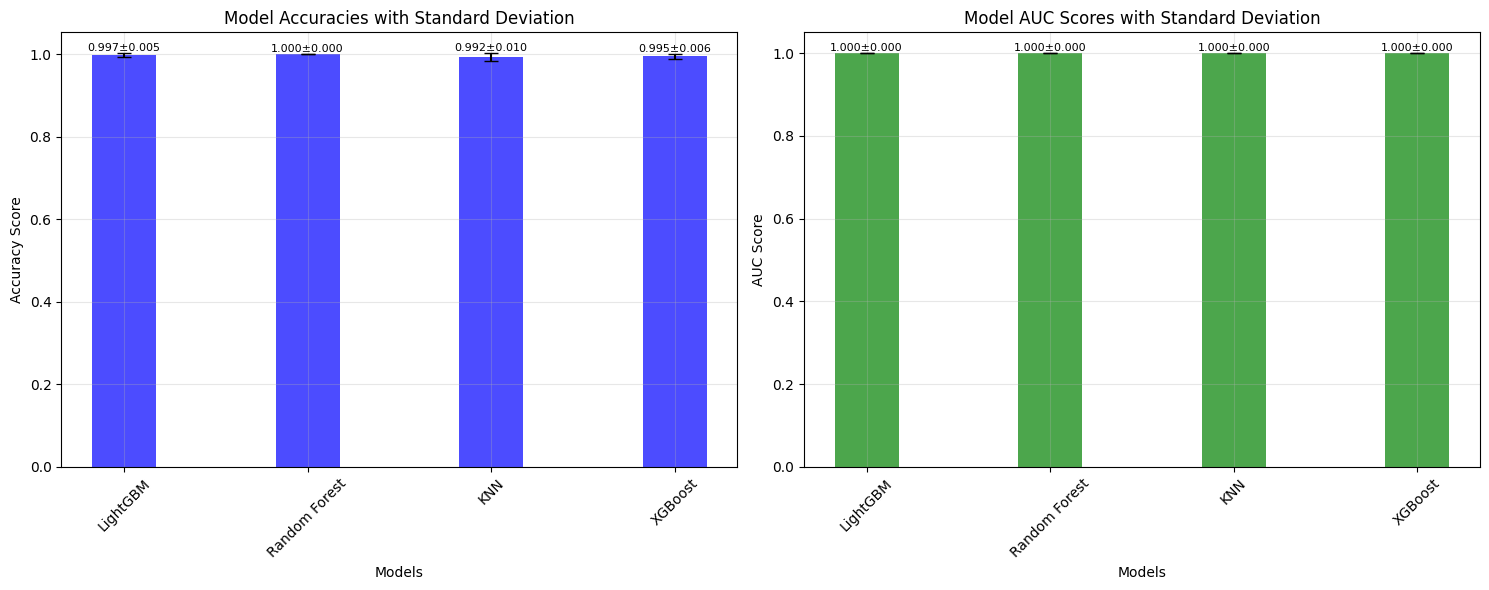


Numerical Results:
------------------------------------------------------------
Model           Accuracy             AUC                 
------------------------------------------------------------
LightGBM        0.997±0.005    1.000±0.000
Random Forest   1.000±0.000    1.000±0.000
KNN             0.992±0.010    1.000±0.000
XGBoost         0.995±0.006    1.000±0.000


In [22]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.model_selection import cross_val_score

def plot_metrics_comparison(models, X_train_reduced, X_test_reduced, y_train, y_test):
    """
    Plot accuracy and AUC scores for different models
    
    Parameters:
    - models: Dictionary of models {model_name: model_instance}
    - X_train_reduced: Reduced feature training set
    - X_test_reduced: Reduced feature test set
    - y_train: Training labels
    - y_test: Test labels
    """
    # Lists to store metrics
    names = []
    accuracies = []
    aucs = []
    accuracy_stds = []
    auc_stds = []
    
    # Calculate metrics for each model
    for name, model in models.items():
        # Fit model
        model.fit(X_train_reduced, y_train)
        
        # Calculate accuracy and its std using cross-validation
        accuracy_scores = cross_val_score(model, X_train_reduced, y_train, cv=5, scoring='accuracy')
        acc_mean = accuracy_scores.mean()
        acc_std = accuracy_scores.std()
        
        # Calculate AUC and its std using cross-validation
        auc_scores = cross_val_score(model, X_train_reduced, y_train, cv=5, scoring='roc_auc')
        auc_mean = auc_scores.mean()
        auc_std = auc_scores.std()
        
        # Store results
        names.append(name)
        accuracies.append(acc_mean)
        aucs.append(auc_mean)
        accuracy_stds.append(acc_std)
        auc_stds.append(auc_std)
    
    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Bar width
    bar_width = 0.35
    index = np.arange(len(names))
    
    # Plot accuracies
    ax1.bar(index, accuracies, bar_width, yerr=accuracy_stds, capsize=5,
            label='Accuracy', color='blue', alpha=0.7)
    ax1.set_xlabel('Models')
    ax1.set_ylabel('Accuracy Score')
    ax1.set_title('Model Accuracies with Standard Deviation')
    ax1.set_xticks(index)
    ax1.set_xticklabels(names, rotation=45)
    ax1.grid(True, alpha=0.3)
    
    # Add accuracy values on top of bars
    for i, v in enumerate(accuracies):
        ax1.text(i, v + accuracy_stds[i], f'{v:.3f}±{accuracy_stds[i]:.3f}', 
                ha='center', va='bottom', fontsize=8)
    
    # Plot AUC scores
    ax2.bar(index, aucs, bar_width, yerr=auc_stds, capsize=5,
            label='AUC', color='green', alpha=0.7)
    ax2.set_xlabel('Models')
    ax2.set_ylabel('AUC Score')
    ax2.set_title('Model AUC Scores with Standard Deviation')
    ax2.set_xticks(index)
    ax2.set_xticklabels(names, rotation=45)
    ax2.grid(True, alpha=0.3)
    
    # Add AUC values on top of bars
    for i, v in enumerate(aucs):
        ax2.text(i, v + auc_stds[i], f'{v:.3f}±{auc_stds[i]:.3f}', 
                ha='center', va='bottom', fontsize=8)
    
    # Adjust layout and display
    plt.tight_layout()
    plt.show()
    
    # Print numerical results
    print("\nNumerical Results:")
    print("-" * 60)
    print(f"{'Model':<15} {'Accuracy':<20} {'AUC':<20}")
    print("-" * 60)
    for i, name in enumerate(names):
        print(f"{name:<15} {accuracies[i]:.3f}±{accuracy_stds[i]:.3f}    {aucs[i]:.3f}±{auc_stds[i]:.3f}")

# Define models (same as before)
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

models = {
    'LightGBM': LGBMClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Plot metrics comparison
plot_metrics_comparison(models, X_train_reduced, X_test_reduced, y_train, y_test)

Number of common features across all datasets: 25

Evaluating LightGBM:
  On Original...
[LightGBM] [Info] Number of positive: 222, number of negative: 174
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006413 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2653
[LightGBM] [Info] Number of data points in the train set: 396, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.560606 -> initscore=0.243622
[LightGBM] [Info] Start training from score 0.243622
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

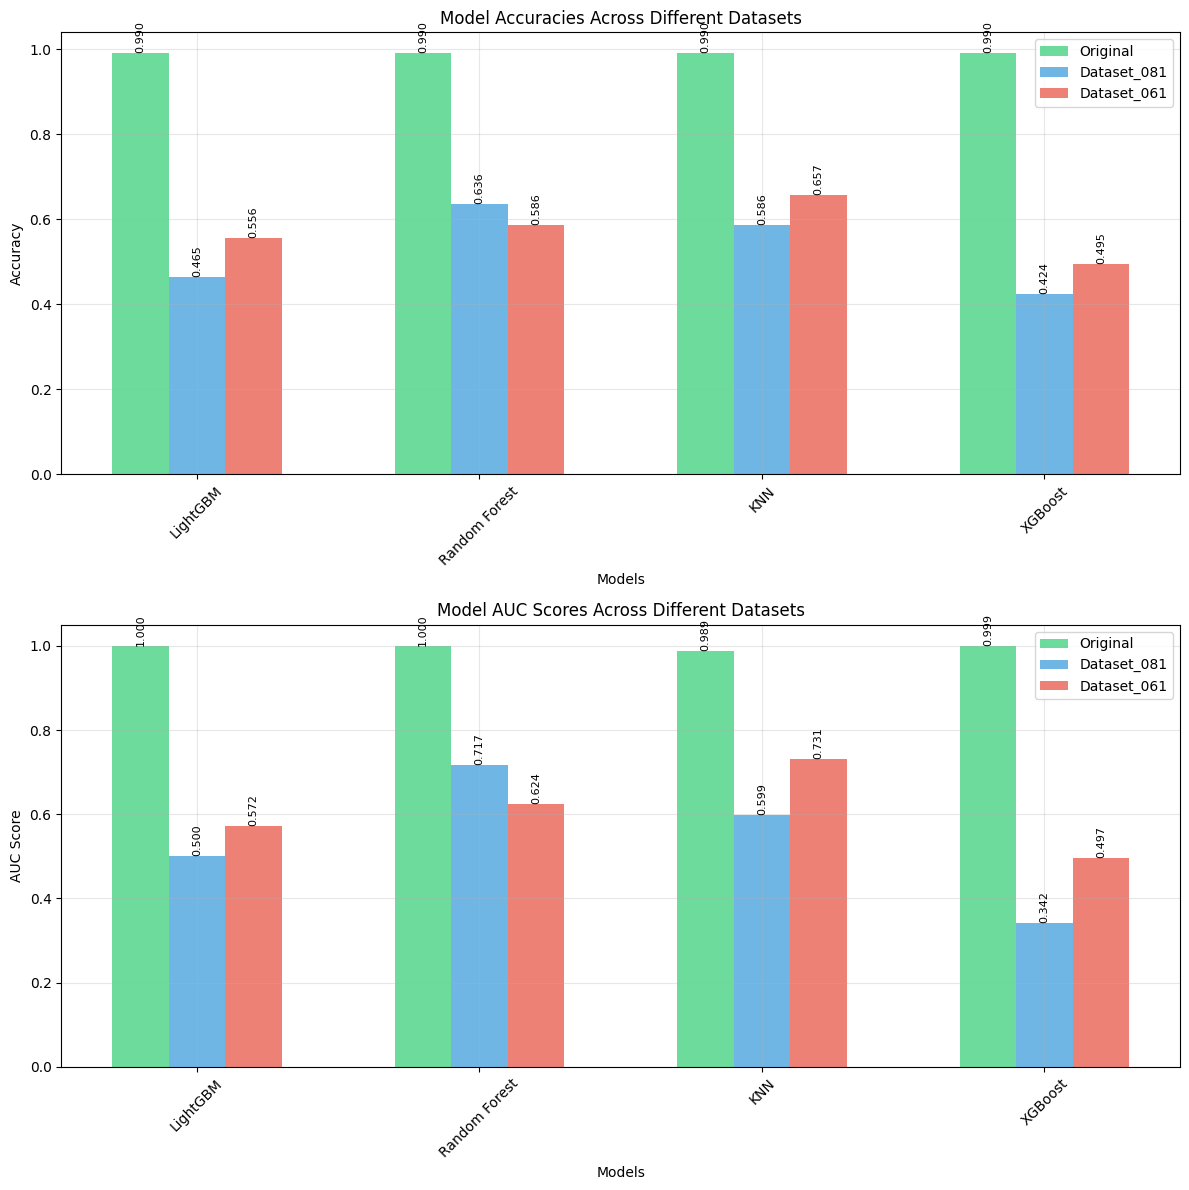


Numerical Results:
--------------------------------------------------------------------------------
Model           Dataset         Accuracy   AUC       
--------------------------------------------------------------------------------
LightGBM        Original        0.990     1.000
LightGBM        Dataset_081     0.465     0.500
LightGBM        Dataset_061     0.556     0.572
Random Forest   Original        0.990     1.000
Random Forest   Dataset_081     0.636     0.717
Random Forest   Dataset_061     0.586     0.624
KNN             Original        0.990     0.989
KNN             Dataset_081     0.586     0.599
KNN             Dataset_061     0.657     0.731
XGBoost         Original        0.990     0.999
XGBoost         Dataset_081     0.424     0.342
XGBoost         Dataset_061     0.495     0.497


In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_curve, auc

def get_common_features(datasets_dict, valid_common_features):
    """Find features that are common across all datasets"""
    # Get features from original dataset
    original_features = set(valid_common_features)
    
    # Get features from each dataset
    dataset_081_features = set(datasets_dict['dataset_081'].columns)
    dataset_061_features = set(datasets_dict['dataset_061'].columns)
    
    # Find intersection of all feature sets
    common_features = original_features.intersection(dataset_081_features).intersection(dataset_061_features)
    
    # Remove 'label' if it's in the features
    if 'label' in common_features:
        common_features.remove('label')
    
    print(f"Number of common features across all datasets: {len(common_features)}")
    return list(common_features)

def evaluate_model_on_dataset(model, X_train, y_train, X_test, y_test):
    """Evaluate a model on a single dataset"""
    # Fit model
    model.fit(X_train, y_train)
    
    # Get predictions
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Calculate AUC
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = auc(fpr, tpr)
    except:
        auc_score = None
    
    return accuracy, auc_score

def plot_multi_dataset_comparison(models, datasets):
    """Plot accuracy comparison across multiple datasets"""
    # Lists to store results
    model_names = list(models.keys())
    dataset_names = list(datasets.keys())
    results = {name: {'accuracy': [], 'auc': []} for name in model_names}
    
    # Evaluate each model on each dataset
    for model_name, model in models.items():
        print(f"\nEvaluating {model_name}:")
        for dataset_name, (X_train, X_test, y_train, y_test) in datasets.items():
            print(f"  On {dataset_name}...")
            accuracy, auc_score = evaluate_model_on_dataset(model, X_train, y_train, X_test, y_test)
            results[model_name]['accuracy'].append(accuracy)
            results[model_name]['auc'].append(auc_score)
    
    # Create bar plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))
    
    # Bar width and positions
    bar_width = 0.2
    r = np.arange(len(model_names))
    
    # Colors for different datasets
    colors = ['#2ecc71', '#3498db', '#e74c3c']
    
    # Plot accuracies
    for i, dataset_name in enumerate(dataset_names):
        accuracies = [results[model_name]['accuracy'][i] for model_name in model_names]
        bars = ax1.bar(r + i*bar_width, accuracies, bar_width, 
                      label=dataset_name, color=colors[i], alpha=0.7)
        
        # Add accuracy values on top of bars
        for j, acc in enumerate(accuracies):
            ax1.text(r[j] + i*bar_width, acc, f'{acc:.3f}', 
                    ha='center', va='bottom', rotation=90, fontsize=8)
    
    # Customize accuracy plot
    ax1.set_xlabel('Models')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Model Accuracies Across Different Datasets')
    ax1.set_xticks(r + bar_width)
    ax1.set_xticklabels(model_names, rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot AUC scores
    for i, dataset_name in enumerate(dataset_names):
        aucs = [results[model_name]['auc'][i] for model_name in model_names]
        bars = ax2.bar(r + i*bar_width, aucs, bar_width, 
                      label=dataset_name, color=colors[i], alpha=0.7)
        
        # Add AUC values on top of bars
        for j, auc_score in enumerate(aucs):
            if auc_score is not None:
                ax2.text(r[j] + i*bar_width, auc_score, f'{auc_score:.3f}', 
                        ha='center', va='bottom', rotation=90, fontsize=8)
    
    # Customize AUC plot
    ax2.set_xlabel('Models')
    ax2.set_ylabel('AUC Score')
    ax2.set_title('Model AUC Scores Across Different Datasets')
    ax2.set_xticks(r + bar_width)
    ax2.set_xticklabels(model_names, rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print numerical results
    print("\nNumerical Results:")
    print("-" * 80)
    print(f"{'Model':<15} {'Dataset':<15} {'Accuracy':<10} {'AUC':<10}")
    print("-" * 80)
    for model_name in model_names:
        for i, dataset_name in enumerate(dataset_names):
            acc = results[model_name]['accuracy'][i]
            auc_score = results[model_name]['auc'][i]
            auc_str = f"{auc_score:.3f}" if auc_score is not None else "N/A"
            print(f"{model_name:<15} {dataset_name:<15} {acc:.3f}     {auc_str}")

# Load your datasets
dataset_081 = pd.read_csv('resampled_train_data_081.csv')
dataset_061 = pd.read_csv('resampled_train_data_061.csv')

# Get common features across all datasets
datasets_dict = {
    'original': pd.DataFrame(X_train_reduced),
    'dataset_081': dataset_081,
    'dataset_061': dataset_061
}
common_features = get_common_features(datasets_dict, valid_common_features)

# Prepare datasets dictionary with only common features
datasets = {
    'Original': (X_train_reduced[common_features], 
                X_test_reduced[common_features], 
                y_train, 
                y_test),
    'Dataset_081': (dataset_081[common_features], 
                   X_test_reduced[common_features], 
                   dataset_081['label'], 
                   y_test),
    'Dataset_061': (dataset_061[common_features], 
                   X_test_reduced[common_features], 
                   dataset_061['label'], 
                   y_test)
}

# Define models
models = {
    'LightGBM': LGBMClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Plot comparison
plot_multi_dataset_comparison(models, datasets)

In [ ]:
import pandas as pd

# Load the test dataset
test_data_path = "test.csv"  # Replace with the path to your test.csv file
test_data = pd.read_csv(test_data_path)

# Ensure the test data has the same features as the trained model
required_features = valid_common_features  # Use the features used in training
missing_features = [feature for feature in required_features if feature not in test_data.columns]

if missing_features:
    print(f"Missing features in test data: {missing_features}")
    raise ValueError("Test data does not have all required features!")

# Select only the required features for prediction
X_test_new = test_data[required_features]

# Make predictions using the trained model
y_pred_new = lgbm.predict(X_test_new)

# Add predictions to the test data for analysis
test_data["Predicted_Label"] = y_pred_new

# Value counts for each category in the predictions
category_counts = test_data["Predicted_Label"].value_counts()
print("\nPrediction Value Counts:")
print(category_counts)

# Save the predictions to a new CSV file
output_path = "test_predictions.csv"
test_data.to_csv(output_path, index=False)
print(f"\nPredictions saved to {output_path}")


In [28]:



manual_features_test1 = [
    "total_features", "praat_count", "os_pcm_fftMag_spectralSlope_sma_upleveltime90",
    "os_pcm_zcr_sma_min", "os_audspec_lengthL1norm_sma_leftctime", "os_audspec_lengthL1norm_sma_kurtosis",	
    "lb_global_mfcc_mean", "os_voiceProb_sma_linregc1", "os_audspec_lengthL1norm_sma_maxSegLen", "os_pcm_zcr_sma_linregc2",	
    "os_pcm_zcr_sma_de_skewness", "os_audspec_lengthL1norm_sma_meanSegLen", "os_audspecRasta_lengthL1norm_sma_maxPos",
    "os_slope500-1500_sma3", "opensmile_count", "os_pcm_loudness_sma_minPos", "os_F0_sma_linregc1",
    "os_audspec_lengthL1norm_sma_upleveltime25", "os_logHNR_sma_de_lpc1", "os_pcm_fftMag_spectralEntropy_sma_de_minPos",
    "librosa_count", "os_pcm_zcr_sma_maxPos", "os_audspec_lengthL1norm_sma_upleveltime90",
    "os_audspec_lengthL1norm_sma_maxPos", "os_audspec_lengthL1norm_sma_upleveltime75"
]


# Replace common_features with manual features
common_features = set(manual_features_test1)
print(f"\nManual Top Features ({len(common_features)}): {common_features}")

# Ensure the features exist in the dataset
valid_common_features = [feature for feature in common_features if feature in X_train.columns]
print(f"\nValid Top Features ({len(valid_common_features)}): {valid_common_features}")

# Use valid features for LightGBM or further analysis
X_train_reduced = X_train[valid_common_features]
X_test_reduced = X_test[valid_common_features]

# Train LightGBM on reduced features
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train_reduced, y_train)
y_pred_lgbm = lgbm.predict(X_test_reduced)

# Evaluate LightGBM
from sklearn.metrics import accuracy_score, classification_report
print("\nLightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("\nLightGBM Classification Report:")
print(classification_report(y_test, y_pred_lgbm))



Manual Top Features (25): {'total_features', 'os_audspec_lengthL1norm_sma_upleveltime75', 'os_pcm_zcr_sma_linregc2', 'os_pcm_fftMag_spectralSlope_sma_upleveltime90', 'os_audspec_lengthL1norm_sma_upleveltime25', 'librosa_count', 'os_audspec_lengthL1norm_sma_kurtosis', 'os_pcm_zcr_sma_de_skewness', 'os_pcm_zcr_sma_min', 'opensmile_count', 'os_audspec_lengthL1norm_sma_maxPos', 'os_audspec_lengthL1norm_sma_leftctime', 'os_F0_sma_linregc1', 'os_pcm_loudness_sma_minPos', 'os_pcm_zcr_sma_maxPos', 'lb_global_mfcc_mean', 'praat_count', 'os_audspecRasta_lengthL1norm_sma_maxPos', 'os_audspec_lengthL1norm_sma_meanSegLen', 'os_voiceProb_sma_linregc1', 'os_pcm_fftMag_spectralEntropy_sma_de_minPos', 'os_audspec_lengthL1norm_sma_maxSegLen', 'os_slope500-1500_sma3', 'os_logHNR_sma_de_lpc1', 'os_audspec_lengthL1norm_sma_upleveltime90'}

Valid Top Features (25): ['total_features', 'os_audspec_lengthL1norm_sma_upleveltime75', 'os_pcm_zcr_sma_linregc2', 'os_pcm_fftMag_spectralSlope_sma_upleveltime90', 'os

In [29]:
import pandas as pd

# Load the test dataset
test_data_path = "resampled_train_data_081.csv"  # Replace with the path to your test.csv file
test_data = pd.read_csv(test_data_path)

# Ensure the test data has the same features as the trained model
required_features = valid_common_features  # Use the features used in training
missing_features = [feature for feature in required_features if feature not in test_data.columns]

if missing_features:
    print(f"Missing features in test data: {missing_features}")
    raise ValueError("Test data does not have all required features!")

# Select only the required features for prediction
X_test_new = test_data[required_features]

# Make predictions using the trained model
y_pred_new = lgbm.predict(X_test_new)

# Add predictions to the test data for analysis
test_data["Predicted_Label"] = y_pred_new

# Value counts for each category in the predictions
category_counts = test_data["Predicted_Label"].value_counts()
print("\nPrediction Value Counts:")
print(category_counts)

# Save the predictions to a new CSV file
output_path = "test_predictions.csv"
test_data.to_csv(output_path, index=False)
print(f"\nPredictions saved to {output_path}")



Prediction Value Counts:
Predicted_Label
1    18
0    16
Name: count, dtype: int64

Predictions saved to test_predictions.csv



Model Performance Metrics:
Accuracy: 0.6176

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.59      0.61        17
           1       0.61      0.65      0.63        17

    accuracy                           0.62        34
   macro avg       0.62      0.62      0.62        34
weighted avg       0.62      0.62      0.62        34


Confusion Matrix:
[[10  7]
 [ 6 11]]


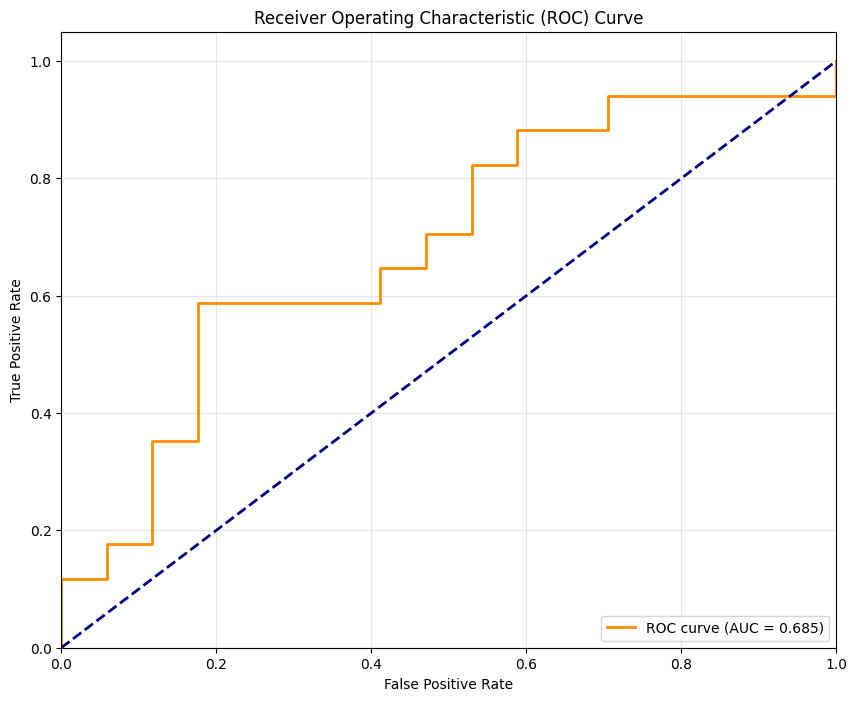


Per-Class Accuracies:
Class 0 Accuracy: 0.5882
Class 1 Accuracy: 0.6471

Prediction Value Counts:
Predicted_Label
1    18
0    16
Name: count, dtype: int64

Detailed Metrics for Each Class:
True Negatives: 10
False Positives: 7
False Negatives: 6
True Positives: 11

Sensitivity (True Positive Rate): 0.6471
Specificity (True Negative Rate): 0.5882

Predictions saved to test_predictions.csv


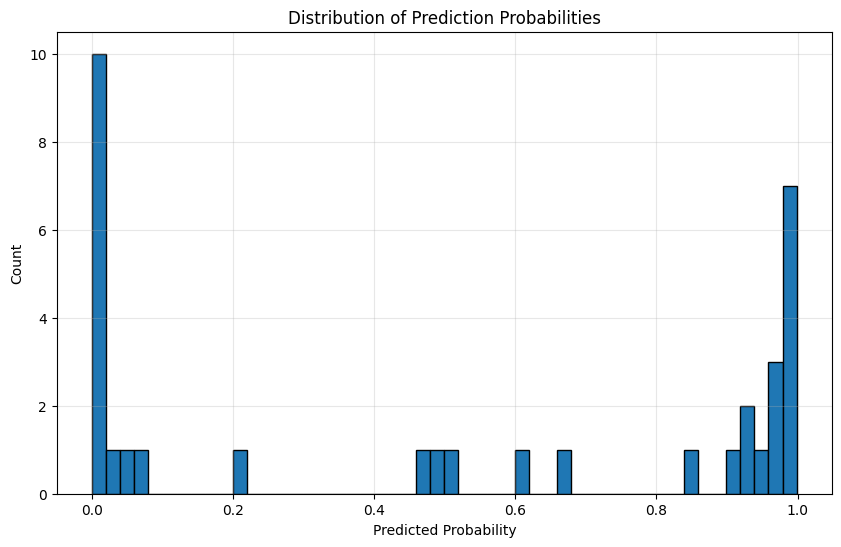

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_curve, auc, classification_report, confusion_matrix
import numpy as np

# Load the test dataset
test_data_path = "resampled_train_data_081.csv"
test_data = pd.read_csv(test_data_path)

# Ensure the test data has the same features as the trained model
required_features = valid_common_features  # Use the features used in training
missing_features = [feature for feature in required_features if feature not in test_data.columns]

if missing_features:
    print(f"Missing features in test data: {missing_features}")
    raise ValueError("Test data does not have all required features!")

# Select only the required features for prediction
X_test_new = test_data[required_features]
y_test_new = test_data['label']  # Assuming 'label' is your target column

# Make predictions using the trained model
y_pred_new = lgbm.predict(X_test_new)
y_pred_proba = lgbm.predict_proba(X_test_new)[:, 1]  # Probability predictions for ROC curve

# Add predictions to the test data for analysis
test_data["Predicted_Label"] = y_pred_new

# Calculate and print accuracy metrics
accuracy = accuracy_score(y_test_new, y_pred_new)
print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")

# Print detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test_new, y_pred_new))

# Print confusion matrix
conf_matrix = confusion_matrix(y_test_new, y_pred_new)
print("\nConfusion Matrix:")
print(conf_matrix)

# Calculate and plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test_new, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Calculate per-class accuracies
class_accuracies = {}
for label in np.unique(y_test_new):
    mask = y_test_new == label
    class_acc = accuracy_score(y_test_new[mask], y_pred_new[mask])
    class_accuracies[f"Class {label} Accuracy"] = class_acc

print("\nPer-Class Accuracies:")
for class_name, acc in class_accuracies.items():
    print(f"{class_name}: {acc:.4f}")

# Value counts for each category in the predictions
category_counts = test_data["Predicted_Label"].value_counts()
print("\nPrediction Value Counts:")
print(category_counts)

# Additional metrics
print("\nDetailed Metrics for Each Class:")
print(f"True Negatives: {conf_matrix[0,0]}")
print(f"False Positives: {conf_matrix[0,1]}")
print(f"False Negatives: {conf_matrix[1,0]}")
print(f"True Positives: {conf_matrix[1,1]}")

# Calculate sensitivity and specificity
sensitivity = conf_matrix[1,1] / (conf_matrix[1,1] + conf_matrix[1,0])
specificity = conf_matrix[0,0] / (conf_matrix[0,0] + conf_matrix[0,1])
print(f"\nSensitivity (True Positive Rate): {sensitivity:.4f}")
print(f"Specificity (True Negative Rate): {specificity:.4f}")

# Save the predictions to a new CSV file
output_path = "test_predictions.csv"
test_data.to_csv(output_path, index=False)
print(f"\nPredictions saved to {output_path}")

# Calculate prediction probabilities distribution
plt.figure(figsize=(10, 6))
plt.hist(y_pred_proba, bins=50, edgecolor='black')
plt.title('Distribution of Prediction Probabilities')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()